In [ ]:
#Step 1 : Elbow Method (K Means)
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import datasets
from sklearn.cluster import KMeans

In [ ]:
#Step 2 : Load datasets
iris = datasets.load_iris()
X = pd.DataFrame(iris.data,columns=iris.feature_names)
X_visual = X[['petal length (cm)','petal width (cm)']]

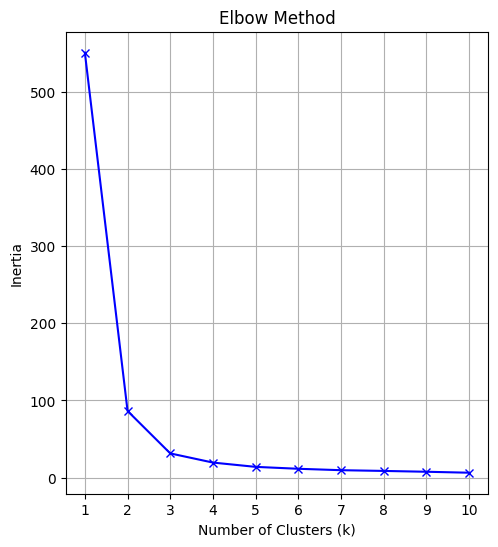

In [ ]:
#Step 3 : Find the optimal number of cluster (k) using the elbow method
inertia=[]
K_range = range(1,11)
for k in K_range:
   kmeans_model=KMeans(n_clusters=k ,n_init='auto',random_state=42)
   kmeans_model.fit(X_visual)
   inertia.append(kmeans_model.inertia_)

#Plotting the elbow method graph
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title('Elbow Method')
plt.plot(K_range,inertia,'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.xticks(K_range)
plt.show()

In [ ]:
#Step 4 : Apply k_means with the optimal k;
optimal_k=3
kmeans=KMeans(n_clusters=optimal_k,n_init='auto',random_state=42)
y_means = kmeans.fit_predict(X_visual)
centroids=kmeans.cluster_centers_

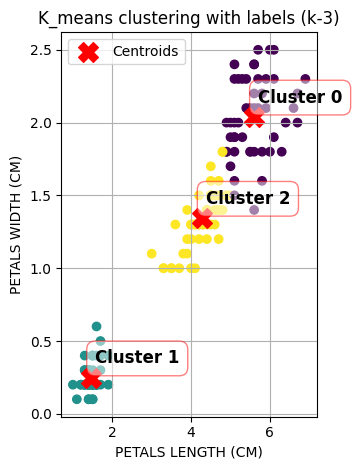

In [ ]:
#Step 5 : VISUALIZE THE CLUSTERING RESULTS WITH LABELS
plt.subplot(1,2,2)

#Plot the data points colored by cluster
plt.scatter(X_visual['petal length (cm)'],X_visual['petal width (cm)'],c=y_means)

#Plot the centroids
plt.scatter(centroids[:,0],centroids[:,1],s=200,marker='X',c='red',label='Centroids')

#Step 6 : Add the labels for each cluster centroids
for i ,center in enumerate(centroids):
 label_text = f'Cluster {i}'
 plt.text(center[0]+0.1,center[1]+0.1, label_text, # Use plt.text and the
            fontsize=12,
            fontweight='bold',
            bbox=dict(facecolor='white',alpha=0.5 ,edgecolor='red',boxstyle='round,pad=0.5'))
plt.title(f'K_means clustering with labels (k-{optimal_k})')
plt.xlabel('PETALS LENGTH (CM)')
plt.ylabel('PETALS WIDTH (CM)')
plt.legend()
plt.grid(True)
plt.tight_layout()

#Display the plots the programs will pause here until you close the plots
plt.show()

In [ ]:
#Step 7 : Display th evaluaton report
#This part  runs after you close the plot window
#We use the true labels (which the algorithm never saw)to check our comparison
comparison_df=pd.DataFrame({
'K-means cluster':y_means,
'actual species':iris.target_names[iris.target]
})

#creates a cross-tabulation to see how cluster map to actual species
evaluation_table=pd.crosstab(comparison_df['K-means cluster'],comparison_df['actual species'])
print('....Evaluation report:Comparing clusters to Actual species____')
print("notes: the algorithm did not use these labels during the clustering process")
print(evaluation_table)

....Evaluation report:Comparing clusters to Actual species____
notes: the algorithm did not use these labels during the clustering process
actual species   setosa  versicolor  virginica
K-means cluster                               
0                     0           2         46
1                    50           0          0
2                     0          48          4
